In [1]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

In [15]:

def load_cell_images(cell_images_dir):
  
    cell_images = {}
    for filename in tqdm(os.listdir(cell_images_dir), desc="Loading cell images"):
        if filename.endswith('.npy'):
            cell_id = int(filename.split('_')[1].split('.')[0])  # 从文件名中提取cell_id
            image_path = os.path.join(cell_images_dir, filename)
            cell_images[cell_id] = np.load(image_path)
    return cell_images

def match_cells_with_images(cell_boundaries_path, cell_images):
   
    cell_boundaries = pd.read_csv(cell_boundaries_path)
    
    cell_boundaries['image'] = cell_boundaries['cell_id'].map(cell_images)
    
    return cell_boundaries


cell_images_dir = './'
cell_boundaries_path = 'data/Xenium/breast_cancer/outs/cell_boundaries.csv.gz'


cell_images = load_cell_images(cell_images_dir)


matched_data = match_cells_with_images(cell_boundaries_path, cell_images)



Loading cell images: 100%|██████████| 46/46 [00:00<00:00, 4242.35it/s]


In [16]:

first_cell_image = matched_data.iloc[0]['image']
print(f"First cell image shape: {first_cell_image.shape}")

First cell image shape: (1, 1, 3)


In [17]:
image = cv2.cvtColor(first_cell_image, cv2.COLOR_RGB2BGR)

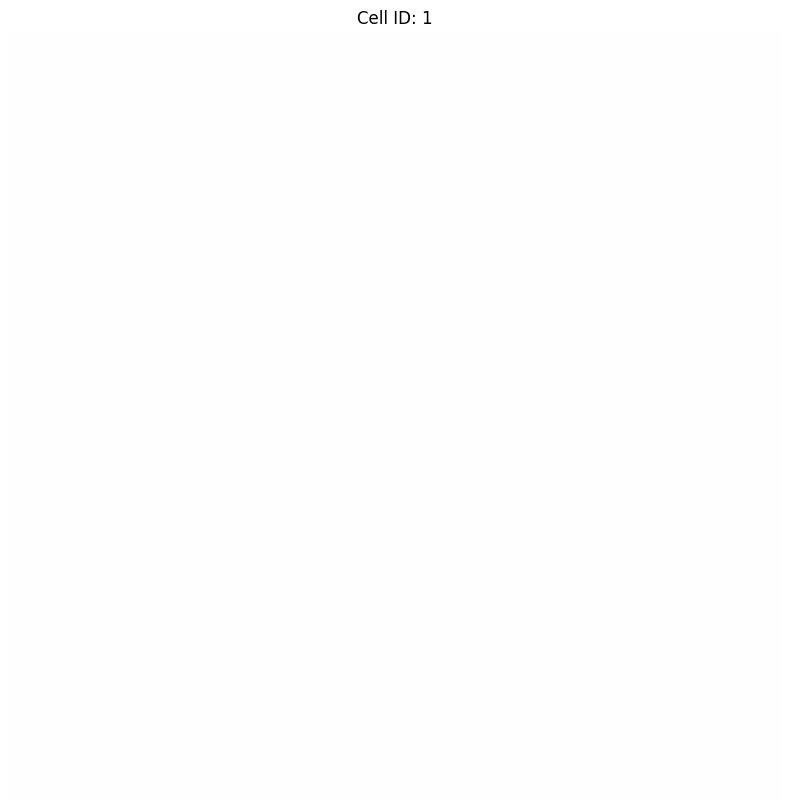

In [18]:
plt.figure(figsize=(10, 10))
plt.imshow(first_cell_image)
plt.title(f"Cell ID: {matched_data.iloc[0]['cell_id']}")
plt.axis('off') 
plt.show()

In [17]:
cv2.imshow('HE Image', image)

: 

: 

: 

In [1]:
import os
import struct
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def get_image_size(file_path):
    """获取图像尺寸而不打开整个文件"""
    try:
        with open(file_path, 'rb') as f:
            head = f.read(24)
            if len(head) != 24:
                return file_path, (0, 0)
            
            if head.startswith(b'\x89PNG\r\n\x1a\n'):
                check = struct.unpack('>i', head[14:18])[0]
                width, height = struct.unpack('>ii', head[16:24])
            elif head[:4] == b'\xff\xd8\xff\xe0':
                f.seek(0)  # Read whole file
                size = 2
                ftype = 0
                while not 0xc0 <= ftype <= 0xcf:
                    f.seek(size, 1)
                    byte = f.read(1)
                    while ord(byte) == 0xff:
                        byte = f.read(1)
                    ftype = ord(byte)
                    size = struct.unpack('>H', f.read(2))[0] - 2
                f.seek(1, 1)
                height, width = struct.unpack('>HH', f.read(4))
            else:
                return file_path, (0, 0)
            
            return file_path, (width, height)
    except Exception:
        return file_path, (0, 0)

def get_largest_image_size(folder_path):
    image_extensions = {'.png', '.jpg', '.jpeg'}
    
    image_paths = [
        os.path.join(folder_path, filename)
        for filename in os.listdir(folder_path)
        if os.path.splitext(filename.lower())[1] in image_extensions
    ]
    
    largest_size = (0, 0)
    largest_image_path = ""
    
    with ThreadPoolExecutor() as executor:
        # 使用tqdm创建进度条
        for path, size in tqdm(executor.map(get_image_size, image_paths), total=len(image_paths), desc="Processing images"):
            if size < largest_size:
                largest_size = size
                largest_image_path = path
    
    return largest_image_path, largest_size

folder_path = "data/xenium_brca_0"
largest_image_path, largest_size = get_largest_image_size(folder_path)
print(f"Largest image path: {largest_image_path}, Size: {largest_size}")

Processing images: 100%|██████████| 118299/118299 [30:04<00:00, 65.56it/s] 


Largest image path: , Size: (0, 0)


In [ ]:
import os
import struct
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def get_image_size(file_path):
    """获取图像尺寸而不打开整个文件"""
    try:
        with open(file_path, 'rb') as f:
            head = f.read(24)
            if len(head) != 24:
                return file_path, (0, 0)
            
            if head.startswith(b'\x89PNG\r\n\x1a\n'):
                check = struct.unpack('>i', head[14:18])[0]
                width, height = struct.unpack('>ii', head[16:24])
            elif head[:4] == b'\xff\xd8\xff\xe0':
                f.seek(0)  # Read whole file
                size = 2
                ftype = 0
                while not 0xc0 <= ftype <= 0xcf:
                    f.seek(size, 1)
                    byte = f.read(1)
                    while ord(byte) == 0xff:
                        byte = f.read(1)
                    ftype = ord(byte)
                    size = struct.unpack('>H', f.read(2))[0] - 2
                f.seek(1, 1)
                height, width = struct.unpack('>HH', f.read(4))
            else:
                return file_path, (0, 0)
            
            return file_path, (width, height)
    except Exception:
        return file_path, (0, 0)

def get_largest_image_size(folder_path):
    image_extensions = {'.png', '.jpg', '.jpeg'}
    
    image_paths = [
        os.path.join(folder_path, filename)
        for filename in os.listdir(folder_path)
        if os.path.splitext(filename.lower())[1] in image_extensions
    ]
    
    largest_size = (0, 0)
    largest_image_path = ""
    
    with ThreadPoolExecutor() as executor:
        # 使用tqdm创建进度条
        for path, size in tqdm(executor.map(get_image_size, image_paths), total=len(image_paths), desc="Processing images"):
            if size > largest_size:
                largest_size = size
                largest_image_path = path
                
print(f"Largest image path: {largest_image_path}, Size: {largest_size}")